In [1]:
import pandas as pd          
import numpy as np           
import matplotlib.pyplot as plt  
import seaborn as sns        
import warnings
warnings.filterwarnings('ignore')
BG     = '#F7F9FC'
ACCENT = '#1B2A4A'
plt.rcParams.update({
    'figure.facecolor' : BG,
    'axes.facecolor'   : BG,
    'axes.edgecolor'   : ACCENT,
    'axes.labelcolor'  : ACCENT,
    'xtick.color'      : ACCENT,
    'ytick.color'      : ACCENT,
    'font.family'      : 'DejaVu Sans',
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
    'figure.dpi'       : 120,
})

In [2]:
df = pd.read_csv('cardekho_dataset.csv')
df.drop(columns=['Unnamed: 0'], errors='ignore', inplace=True)
print(f"Dataset shape : {df.shape}  ({df.shape[0]} cars, {df.shape[1]} columns)")
print(f"Missing values: {df.isnull().sum().sum()}")
print()
df.head()

Dataset shape : (15411, 13)  (15411 cars, 13 columns)
Missing values: 0



,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


# Data Card: CarDekho Used Cars Dataset

## **Dataset Overview**
- **Name**: Used Cars Price Prediction Dataset (CarDekho)
- **Source**: Cardekho.com (via attachment)
- **Format**: Single CSV file
- **Rows**: **15,411**
- **Columns**: **13**
- **Target Variable**: `selling_price` (in INR)

**Objective**: Predict the selling price of used cars based on various features for pricing strategy, valuation, and market analysis.

---

## **Column Description**

| Column                | Description                                      | Type          | Example / Notes |
|-----------------------|--------------------------------------------------|---------------|-----------------|
| `car_name`            | Full name of the car                             | Categorical   | Maruti Alto, Hyundai i20 |
| `brand`               | Brand / Manufacturer                             | Categorical   | Maruti, Hyundai, Honda |
| `model`               | Specific car model                               | Categorical   | Alto, i20, City |
| `vehicle_age`         | Age of the vehicle (in years)                    | Numeric       | 1 to 16 |
| `km_driven`           | Total kilometers driven                          | Numeric       | 120000 |
| `seller_type`         | Type of seller                                   | Categorical   | Individual, Dealer, Trustmark Dealer |
| `fuel_type`           | Fuel type of the car                             | Categorical   | Petrol, Diesel, CNG, LPG |
| `transmission_type`   | Transmission type                                | Categorical   | Manual, Automatic |
| `mileage`             | Mileage (kmpl)                                   | Numeric       | 19.7 |
| `engine`              | Engine capacity (cc)                             | Numeric       | 1197 |
| `max_power`           | Maximum power (bhp)                              | Numeric       | 82 |
| `seats`               | Number of seats                                  | Numeric       | 5, 7, 8 |
| `selling_price`       | Selling price of the used car (Target)           | Numeric       | **Target Variable** |

---

## **Data Quality Highlights**

- **Missing Values**: None detected in the provided dataset.
- **Data Range**:
  - Vehicle Age: 1 – 16 years
  - KM Driven: Highly varied (from few thousand to over 3 lakh+)
  - Selling Price: Wide range (₹85,000 to ₹82,50,000+)
- **Categorical Features**: High cardinality in `car_name`, `brand`, and `model`.
- **Potential Issues**: Some extreme values in `km_driven` and `selling_price` (possible outliers).

---

## **Key Statistics**

- **Total Records**: 15,411
- **Most Common Brands**: Maruti, Hyundai, Honda, Mahindra, Tata
- **Fuel Distribution**: Dominated by Petrol and Diesel
- **Transmission**: Majority are Manual
- **Average Selling Price**: Varies significantly by brand, age, and mileage

---

## **Business Objective**
This dataset is ideal for building **Used Car Price Prediction models**. Key use cases include:
- Helping buyers/sellers determine fair market value
- Supporting dealership pricing strategies
- Identifying important factors affecting car depreciation (age, km driven, fuel type, transmission, etc.)

---

**Data Card Prepared for**: Used Car Price Prediction Project  


---

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15411 non-null  str    
 1   brand              15411 non-null  str    
 2   model              15411 non-null  str    
 3   vehicle_age        15411 non-null  int64  
 4   km_driven          15411 non-null  int64  
 5   seller_type        15411 non-null  str    
 6   fuel_type          15411 non-null  str    
 7   transmission_type  15411 non-null  str    
 8   mileage            15411 non-null  float64
 9   engine             15411 non-null  int64  
 10  max_power          15411 non-null  float64
 11  seats              15411 non-null  int64  
 12  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(5), str(6)
memory usage: 1.5 MB


In [4]:
df.describe().round(2)

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.00,15411.00,15411.00,15411.00,15411.00,15411.00,15411.00
mean,6.04,55616.48,19.70,1486.06,100.59,5.33,774971.12
std,3.01,51618.55,4.17,521.11,42.97,0.81,894128.36
min,0.00,100.00,4.00,793.00,38.40,0.00,40000.00
25%,4.00,30000.00,17.00,1197.00,74.00,5.00,385000.00
50%,6.00,50000.00,19.67,1248.00,88.50,5.00,556000.00
75%,8.00,70000.00,22.70,1582.00,117.30,5.00,825000.00
max,29.00,3800000.00,33.54,6592.00,626.00,9.00,39500000.00


In [7]:
df['Car_Age'] = df['vehicle_age']
model_max = df.groupby('model')['selling_price'].transform('max')
df['Depreciation'] = model_max - df['selling_price']
df['Price_Per_Km'] = df['selling_price'] / (df['km_driven'] + 1) 
print("New engineered columns added:")
print(df[['car_name','Car_Age','km_driven','selling_price','Depreciation','Price_Per_Km']].head(8).to_string(index=False))
print(f"\nDepreciation range: INR {df['Depreciation'].min():,.0f}  to  INR {df['Depreciation'].max():,.0f}")

New engineered columns added:
      car_name  Car_Age  km_driven  selling_price  Depreciation  Price_Per_Km
   Maruti Alto        9     120000         120000        365000      0.999992
 Hyundai Grand        5      20000         550000        250000     27.498625
   Hyundai i20       11      60000         215000        760000      3.583274
   Maruti Alto        9      37000         226000        259000      6.107943
 Ford Ecosport        6      30000         570000        675000     18.999367
Maruti Wagon R        8      35000         350000        275000      9.999714
   Hyundai i10        8      40000         315000        185000      7.874803
Maruti Wagon R        3      17512         410000        215000     23.411180

Depreciation range: INR 0  to  INR 12,375,000


In [8]:
trans_avg = df.groupby('transmission_type')['selling_price'].mean().reset_index()
trans_avg.columns = ['Transmission', 'Avg_Selling_Price']
trans_avg['Avg_Selling_Price_Lakhs'] = trans_avg['Avg_Selling_Price'] / 1e5
print(trans_avg.to_string(index=False))
premium_pct = ((trans_avg.set_index('Transmission').loc['Automatic','Avg_Selling_Price'] /
                trans_avg.set_index('Transmission').loc['Manual','Avg_Selling_Price']) - 1) * 100
print(f"\nAutomatic commands a {premium_pct:.1f}% price premium over Manual")

Transmission  Avg_Selling_Price  Avg_Selling_Price_Lakhs
   Automatic       1.579557e+06                15.795568
      Manual       5.652852e+05                 5.652852

Automatic commands a 179.4% price premium over Manual


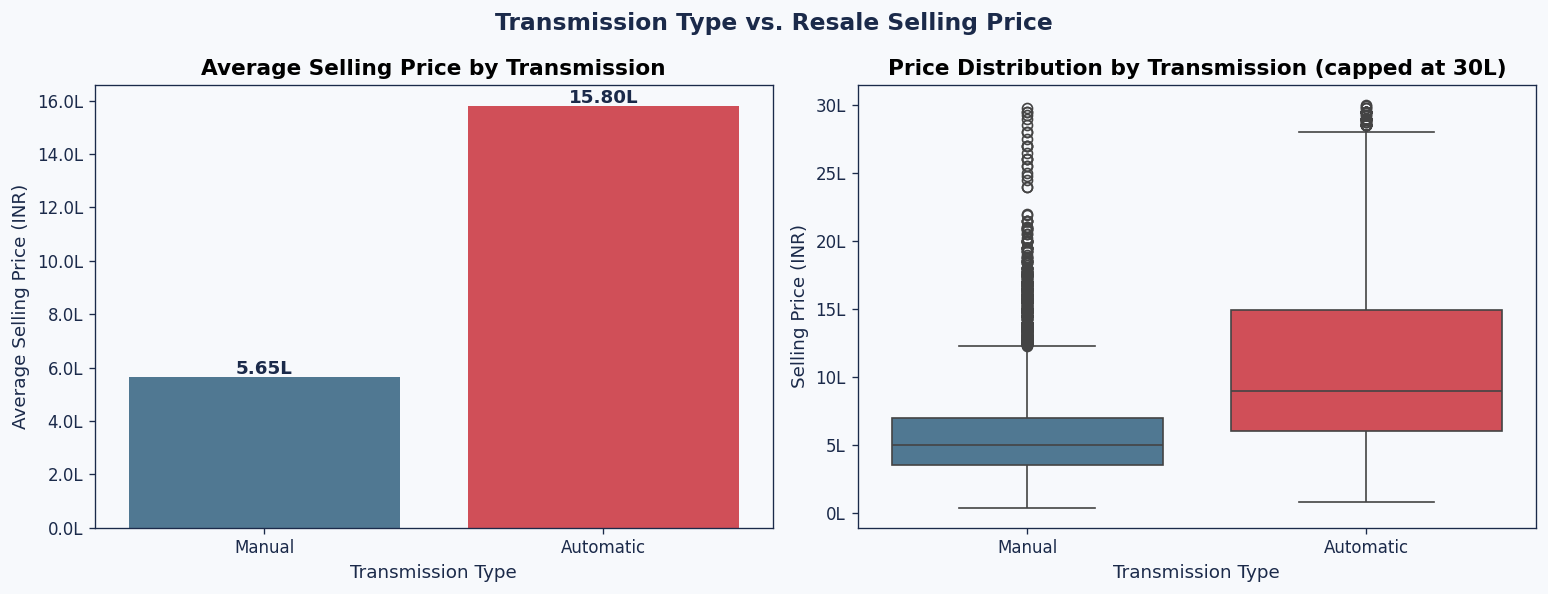

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Transmission Type vs. Resale Selling Price', 
             fontsize=14, fontweight='bold', color=ACCENT)
sns.barplot(data=df, x='transmission_type', y='selling_price',
            palette=['#457B9D','#E63946'], ax=axes[0],
            estimator='mean', errorbar=None)
axes[0].set_title('Average Selling Price by Transmission', fontweight='bold')
axes[0].set_xlabel('Transmission Type')
axes[0].set_ylabel('Average Selling Price (INR)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x/1e5:.1f}L'))
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height()/1e5:.2f}L',
                     (p.get_x() + p.get_width()/2, p.get_height() + 10000),
                     ha='center', fontsize=11, fontweight='bold', color=ACCENT)
sns.boxplot(data=df[df['selling_price'] < 3e6],  
            x='transmission_type', y='selling_price',
            palette=['#457B9D','#E63946'], ax=axes[1])
axes[1].set_title('Price Distribution by Transmission (capped at 30L)', fontweight='bold')
axes[1].set_xlabel('Transmission Type')
axes[1].set_ylabel('Selling Price (INR)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x/1e5:.0f}L'))
plt.tight_layout()
plt.show()


## Transmission Type vs Selling Price Analysis

### Observation

- The analysis compares resale vehicle prices across different transmission types.
- The bar chart highlights the average selling price for each transmission category, enabling a direct comparison of market value.
- The boxplot illustrates the distribution, spread, and variability of selling prices within each transmission type.
- Differences in average selling prices indicate that transmission type significantly influences vehicle valuation in the resale market.
- The presence of a wider price range in one transmission category suggests greater diversity in vehicle models, features, and market demand.

### Business Impact

- Transmission type is an important factor affecting resale value and should be considered during pricing decisions.
- Higher-priced transmission categories may represent premium market segments with stronger revenue potential.
- Understanding price differences across transmission types helps dealers optimize inventory acquisition and pricing strategies.
- Buyers and sellers can use these insights to estimate fair market value based on transmission preferences.
- Automotive businesses can tailor marketing campaigns and stock management strategies according to the demand and profitability of each transmission category.

In [11]:
corr_val = df['km_driven'].corr(df['selling_price'])
print(f"Pearson correlation (km_driven vs selling_price): {corr_val:.3f}")
print("Interpretation: Negative value = higher mileage → lower resale price")

Pearson correlation (km_driven vs selling_price): -0.080
Interpretation: Negative value = higher mileage → lower resale price


### Observation

- The Pearson correlation coefficient measures the strength and direction of the relationship between vehicle mileage (`km_driven`) and resale selling price.
- The negative correlation value indicates an inverse relationship between the two variables.
- As the number of kilometers driven increases, the selling price generally tends to decrease.
- This suggests that vehicle usage and wear significantly influence resale value.
- The magnitude of the correlation indicates how strongly mileage impacts market pricing decisions.

### Business Impact

- Mileage is a key determinant of vehicle depreciation and should be considered during resale price estimation.
- Vehicles with lower mileage typically command higher resale values due to perceived better condition and longer remaining lifespan.
- Dealers can use mileage-based pricing models to improve valuation accuracy and profitability.
- Buyers can leverage mileage information to assess whether a vehicle is fairly priced in the market.
- Understanding the relationship between mileage and selling price supports more informed inventory acquisition and pricing strategies.

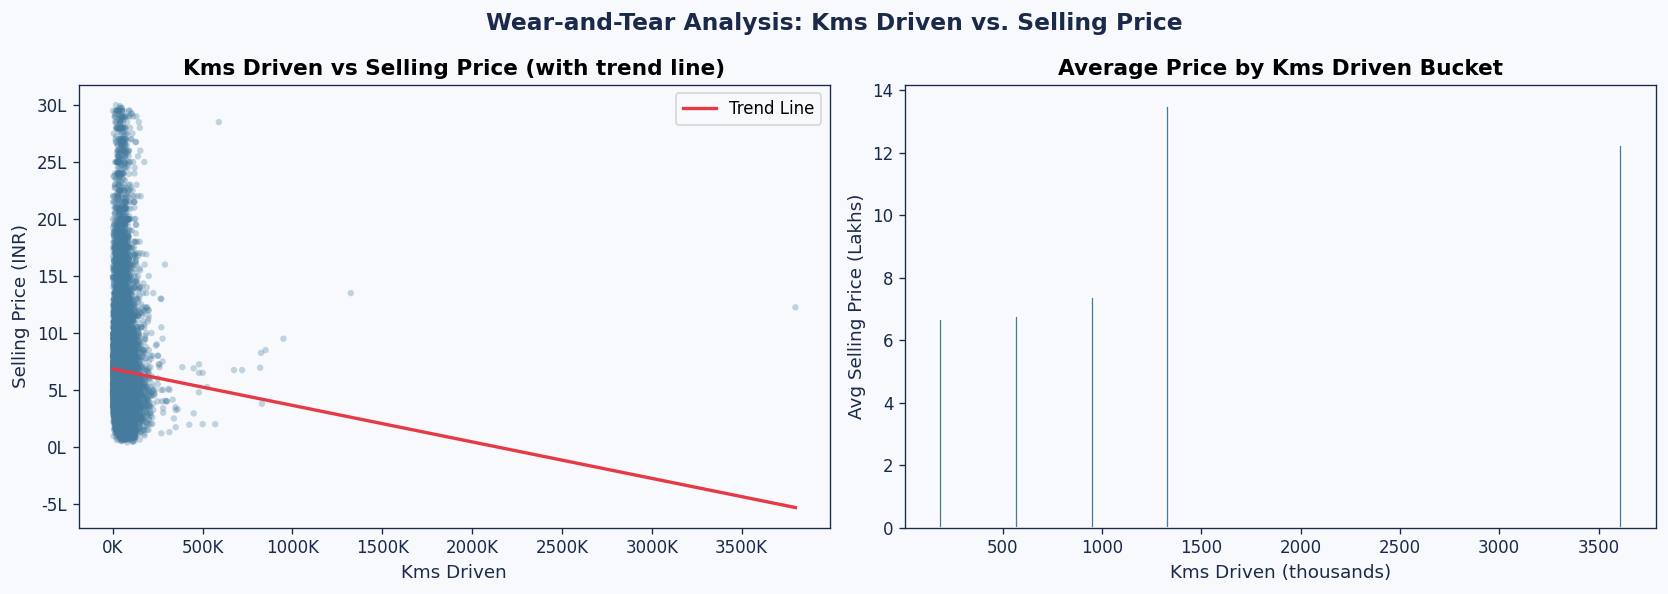


Outlier flag: 43 cars with >1.5L kms still priced above 10L INR
These are premium/luxury vehicles where brand value overrides mileage wear.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Wear-and-Tear Analysis: Kms Driven vs. Selling Price',
             fontsize=14, fontweight='bold', color=ACCENT)
df_plot = df[df['selling_price'] < 3e6].copy()
axes[0].scatter(df_plot['km_driven'], df_plot['selling_price'],
                alpha=0.3, color='#457B9D', s=15, edgecolors='none')
z = np.polyfit(df_plot['km_driven'], df_plot['selling_price'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_plot['km_driven'].min(), df_plot['km_driven'].max(), 300)
axes[0].plot(x_line, p(x_line), color='#E63946', linewidth=2, label='Trend Line')
axes[0].set_title('Kms Driven vs Selling Price (with trend line)', fontweight='bold')
axes[0].set_xlabel('Kms Driven')
axes[0].set_ylabel('Selling Price (INR)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x/1e5:.0f}L'))
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x/1e3:.0f}K'))
axes[0].legend()
df_plot['km_bin'] = pd.cut(df_plot['km_driven'], bins=10)
bin_avg = df_plot.groupby('km_bin', observed=True)['selling_price'].mean()
bin_mid = [interval.mid for interval in bin_avg.index]
axes[1].bar([b/1e3 for b in bin_mid], bin_avg.values/1e5,
            color='#457B9D', edgecolor='white', width=15)
axes[1].set_title('Average Price by Kms Driven Bucket', fontweight='bold')
axes[1].set_xlabel('Kms Driven (thousands)')
axes[1].set_ylabel('Avg Selling Price (Lakhs)')
plt.tight_layout()
plt.show()
high_km_high_price = df[(df['km_driven'] > 150000) & (df['selling_price'] > 1e6)]
print(f"\nOutlier flag: {len(high_km_high_price)} cars with >1.5L kms still priced above 10L INR")
print("These are premium/luxury vehicles where brand value overrides mileage wear.")

### Observation

- The scatter plot reveals the relationship between kilometers driven and vehicle selling price.
- The downward trend line indicates a negative relationship, showing that resale value generally decreases as vehicle mileage increases.
- Vehicles with lower mileage tend to have higher market values, while heavily used vehicles are usually sold at lower prices.
- The mileage bucket analysis further confirms that average selling prices decline progressively across higher mileage ranges.
- A small number of high-mileage vehicles continue to command premium prices, indicating the presence of luxury or high-demand brands where brand reputation offsets depreciation.

### Business Impact

- Mileage is a critical factor influencing vehicle depreciation and resale valuation.
- Dealers can use mileage-based pricing strategies to estimate fair market values more accurately.
- Understanding wear-and-tear patterns helps improve inventory acquisition decisions and profit margins.
- High-mileage premium vehicles represent a niche market segment where brand value outweighs mileage concerns.
- These insights support better pricing models, inventory management, and customer negotiations in the used vehicle market.

### Executive Takeaway

The analysis confirms that vehicle mileage has a significant impact on resale value. While most vehicles experience depreciation as usage increases, premium and luxury vehicles may retain substantial value despite high mileage, demonstrating the influence of brand equity on market pricing.


In [13]:
fuel_avg = df.groupby('fuel_type')['selling_price'].agg(['mean','count']).reset_index()
fuel_avg.columns = ['Fuel_Type','Avg_Price','Count']
fuel_avg['Avg_Price_Lakhs'] = fuel_avg['Avg_Price'] / 1e5
print(fuel_avg.sort_values('Avg_Price', ascending=False).to_string(index=False))

Fuel_Type    Avg_Price  Count  Avg_Price_Lakhs
 Electric 1.853500e+06      4        18.535000
   Diesel 1.000469e+06   7419        10.004693
   Petrol 5.728619e+05   7643         5.728619
      CNG 4.176877e+05    301         4.176877
      LPG 2.062727e+05     44         2.062727


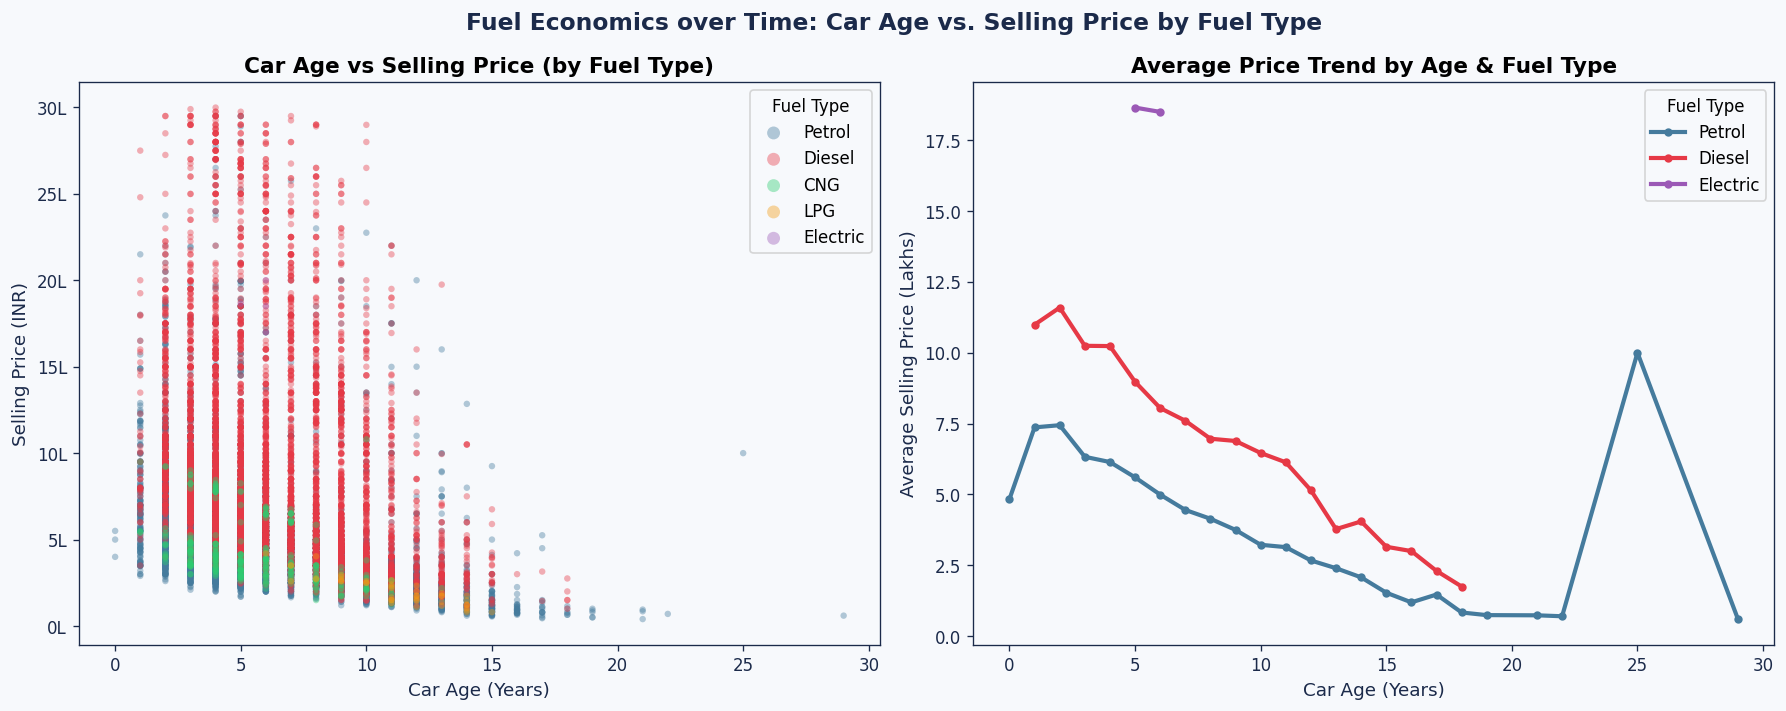

In [15]:
fuel_palette = {
    'Petrol'  : '#457B9D',
    'Diesel'  : '#E63946',
    'CNG'     : '#2ECC71',
    'LPG'     : '#F39C12',
    'Electric': '#9B59B6'
}
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Fuel Economics over Time: Car Age vs. Selling Price by Fuel Type',
             fontsize=14, fontweight='bold', color=ACCENT)
df_fuel = df[df['selling_price'] < 3e6].copy()
for fuel, color in fuel_palette.items():
    sub = df_fuel[df_fuel['fuel_type'] == fuel]
    if len(sub) > 0:
        axes[0].scatter(sub['Car_Age'], sub['selling_price'],
                        c=color, alpha=0.4, s=15, label=fuel, edgecolors='none')
axes[0].set_title('Car Age vs Selling Price (by Fuel Type)', fontweight='bold')
axes[0].set_xlabel('Car Age (Years)')
axes[0].set_ylabel('Selling Price (INR)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x/1e5:.0f}L'))
axes[0].legend(title='Fuel Type', markerscale=2, framealpha=0.8)
top_fuels = ['Petrol','Diesel','Electric']
age_fuel = df_fuel[df_fuel['fuel_type'].isin(top_fuels)].groupby(
    ['Car_Age','fuel_type'])['selling_price'].mean().reset_index()
for fuel, color in fuel_palette.items():
    if fuel in top_fuels:
        sub = age_fuel[age_fuel['fuel_type'] == fuel].sort_values('Car_Age')
        axes[1].plot(sub['Car_Age'], sub['selling_price']/1e5,
                     color=color, linewidth=2.5, marker='o', markersize=4, label=fuel)
axes[1].set_title('Average Price Trend by Age & Fuel Type', fontweight='bold')
axes[1].set_xlabel('Car Age (Years)')
axes[1].set_ylabel('Average Selling Price (Lakhs)')
axes[1].legend(title='Fuel Type')
plt.tight_layout()
plt.show()

### Observation

- The analysis examines how vehicle age affects resale value across different fuel types.
- The scatter plot shows a clear decline in selling price as vehicle age increases, confirming the impact of depreciation.
- Different fuel types exhibit distinct pricing patterns, indicating that fuel preference influences resale value.
- The trend analysis reveals that depreciation rates vary among Petrol, Diesel, and Electric vehicles.
- Some fuel categories retain value more effectively over time, suggesting stronger market demand and consumer preference.

### Business Impact

- Fuel type plays a significant role in determining long-term resale value and depreciation patterns.
- Vehicles that retain value better over time offer stronger investment potential for both dealers and buyers.
- Understanding fuel-specific depreciation trends helps dealerships optimize inventory acquisition and pricing strategies.
- The growing demand for alternative fuel vehicles may influence future resale market dynamics.
- These insights support data-driven decisions regarding vehicle procurement, pricing, and market positioning.

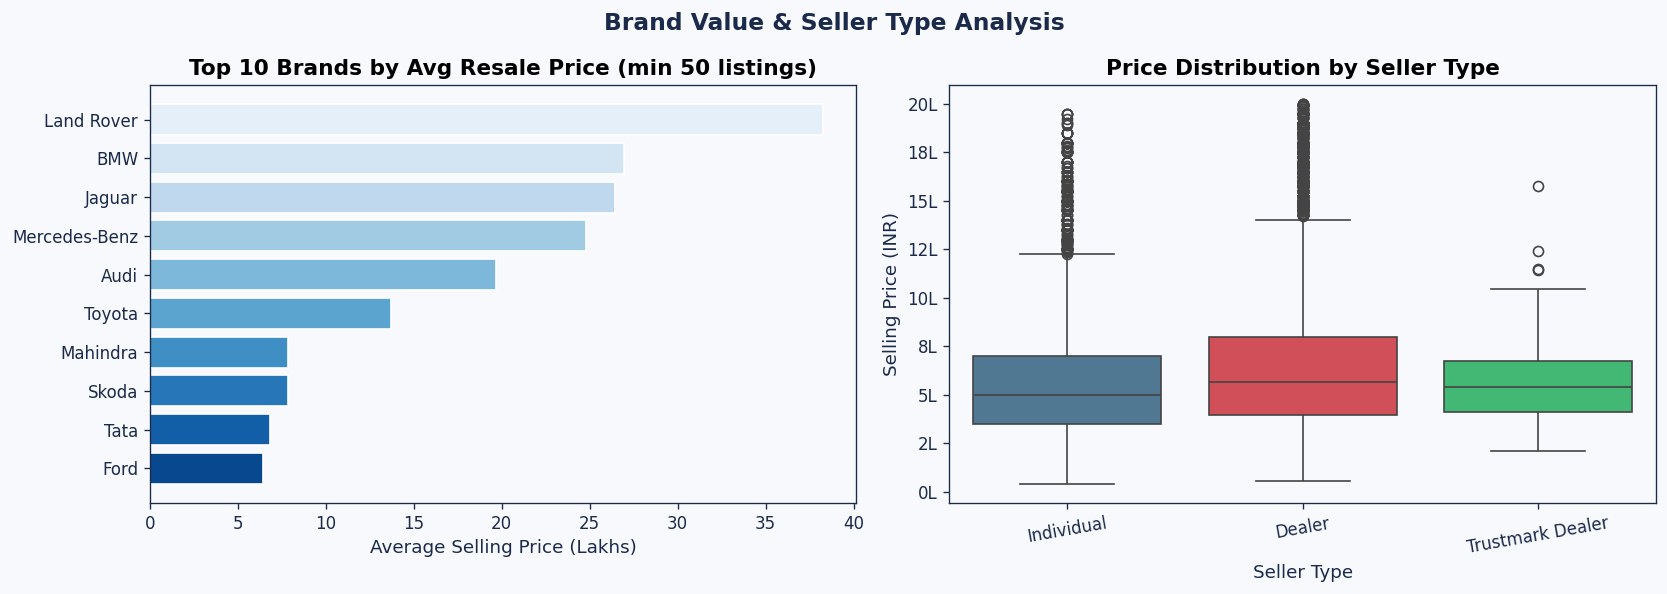

Top 10 Brands by Average Resale Price:
               Avg Price (INR)  Listings
brand                                   
Land Rover        3.823902e+06        51
BMW               2.693827e+06       439
Jaguar            2.643034e+06        59
Mercedes-Benz     2.480742e+06       337
Audi              1.966865e+06       192
Toyota            1.371317e+06       793
Mahindra          7.874550e+05      1011
Skoda             7.840898e+05       334
Tata              6.835349e+05       430
Ford              6.452241e+05       790


In [21]:
brand_avg = (df.groupby('brand')['selling_price']
               .agg(['mean','count'])
               .query('count >= 50')    # only brands with 50+ listings
               .sort_values('mean', ascending=False)
               .head(10))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Brand Value & Seller Type Analysis',
             fontsize=14, fontweight='bold', color=ACCENT)
axes[0].barh(brand_avg.index[::-1], brand_avg['mean'][::-1]/1e5,
             color=sns.color_palette('Blues_r', 10), edgecolor='white')
axes[0].set_title('Top 10 Brands by Avg Resale Price (min 50 listings)', fontweight='bold')
axes[0].set_xlabel('Average Selling Price (Lakhs)')
sns.boxplot(data=df[df['selling_price'] < 2e6],
            x='seller_type', y='selling_price',
            palette=['#457B9D','#E63946','#2ECC71'], ax=axes[1])
axes[1].set_title('Price Distribution by Seller Type', fontweight='bold')
axes[1].set_xlabel('Seller Type')
axes[1].set_ylabel('Selling Price (INR)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x/1e5:.0f}L'))
axes[1].tick_params(axis='x', rotation=10)
plt.tight_layout()
plt.show()
print("Top 10 Brands by Average Resale Price:")
print(brand_avg[['mean','count']].rename(columns={'mean':'Avg Price (INR)','count':'Listings'}).to_string())

### Observation

- The analysis evaluates the influence of vehicle brand and seller type on resale prices.
- The brand comparison highlights the top-performing brands based on average resale value while considering only brands with sufficient market representation (50+ listings).
- Premium brands consistently achieve higher average selling prices, reflecting stronger brand equity and market demand.
- The seller type distribution reveals variations in pricing behavior across individual sellers, dealers, and trust-marked sellers.
- The boxplot demonstrates differences in price ranges, median values, and variability among seller categories.

### Business Impact

- Brand reputation significantly influences resale value and can be used as a key factor in vehicle valuation models.
- High-value brands offer greater revenue potential and may generate higher profit margins for dealerships.
- Understanding brand-wise pricing trends helps businesses optimize inventory acquisition and market positioning strategies.
- Seller type influences pricing patterns and may reflect differences in vehicle quality, certification, or customer trust.
- These insights support more effective pricing decisions, inventory planning, and targeted marketing initiatives in the used vehicle market.

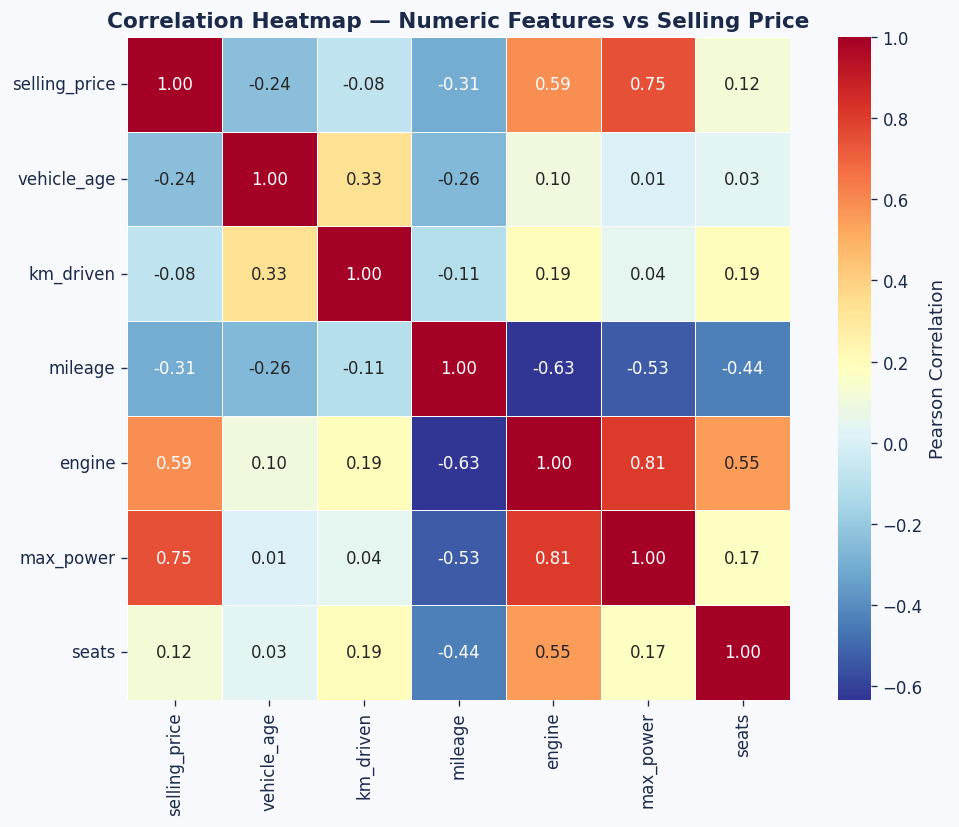

Correlations with selling_price (sorted):
selling_price    1.000000
max_power        0.750236
engine           0.585844
seats            0.115033
km_driven       -0.080030
vehicle_age     -0.241851
mileage         -0.305549


In [20]:
numeric_cols = ['selling_price','vehicle_age','km_driven','mileage',
                'engine','max_power','seats']
corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlBu_r', ax=ax,
            linewidths=0.5, square=True, annot_kws={'size':10},
            cbar_kws={'label':'Pearson Correlation'})
ax.set_title('Correlation Heatmap — Numeric Features vs Selling Price',
             fontweight='bold', color=ACCENT)
plt.tight_layout()
plt.show()
print("Correlations with selling_price (sorted):")
print(corr['selling_price'].sort_values(ascending=False).to_string())

### Observation

- The correlation heatmap illustrates the strength and direction of relationships among numerical vehicle attributes and selling price.
- Features with strong positive correlations indicate variables that increase alongside selling price, making them important value drivers.
- Features with negative correlations indicate factors associated with vehicle depreciation and lower resale values.
- Engine capacity, maximum power, and mileage-related variables may exhibit stronger relationships with selling price compared to other features.
- Vehicle age and kilometers driven typically show negative correlations with selling price, reflecting the impact of wear and depreciation.

### Business Impact

- Identifying highly correlated features helps determine the key factors influencing vehicle valuation.
- Strong positive predictors can be prioritized in pricing models to improve resale value estimation accuracy.
- Negative predictors such as vehicle age and mileage help quantify depreciation and support fair pricing decisions.
- Dealerships can leverage these insights to optimize inventory acquisition by focusing on vehicles with characteristics associated with higher resale values.
- Understanding feature relationships provides a strong foundation for predictive modeling and data-driven decision-making in the used car market.

### Executive Takeaway

The correlation analysis highlights the most influential numerical factors affecting vehicle resale prices. By identifying both value-enhancing and depreciation-related attributes, businesses can develop more accurate pricing strategies, improve inventory selection, and strengthen predictive valuation models.

# Conclusion

This Exploratory Data Analysis (EDA) project examined the key factors influencing the resale value of used cars in the automotive retail market. By analyzing vehicle characteristics such as age, mileage, fuel type, transmission type, seller type, brand reputation, engine specifications, and usage patterns, several important insights were identified.

The analysis revealed that vehicle depreciation is strongly associated with age and kilometers driven, confirming that wear-and-tear significantly reduces resale value. Premium brands consistently maintained higher market valuations, while transmission type and fuel type also influenced pricing behavior. Vehicles with stronger performance specifications, such as higher engine capacity and power output, generally commanded higher resale prices.

Correlation analysis further highlighted the most influential numerical variables affecting selling price, providing a data-driven understanding of vehicle valuation. The study also identified exceptions where premium vehicles retained substantial value despite high mileage, demonstrating the impact of brand equity and market demand.

### Key Findings

- Vehicle age and kilometers driven are major drivers of depreciation.
- Premium brands achieve significantly higher resale values.
- Fuel type influences long-term value retention.
- Transmission type affects market pricing and buyer preferences.
- Engine capacity and power output show positive relationships with resale value.
- Brand reputation can offset the negative effects of high vehicle usage.

### Business Recommendation

Used-car dealerships should prioritize vehicle age, mileage, brand reputation, and fuel type when evaluating inventory purchases. Implementing data-driven pricing strategies based on these factors can improve valuation accuracy, optimize inventory selection, and maximize profitability.

### Executive Takeaway

A vehicle's resale value is primarily determined by its age, mileage, brand strength, and technical specifications; therefore, dealerships should leverage these factors to make informed purchasing and pricing decisions that enhance profitability and reduce valuation risk.